<a href="https://colab.research.google.com/github/shubhankchauhan/phone-book-web-app/blob/master/dermaimage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [63]:
data = np.load("candidate_dataset.npz")

print("Keys in candidate_dataset.npz:", data.files)

x_train = data["x_train"]
y_train = data["y_train"]
x_val   = data["x_val"]
y_val   = data["y_val"]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

Keys in candidate_dataset.npz: ['x_train', 'y_train', 'x_val', 'y_val']
x_train shape: (7007, 28, 28, 3)
y_train shape: (7007, 1)
x_val shape: (1003, 28, 28, 3)
y_val shape: (1003, 1)


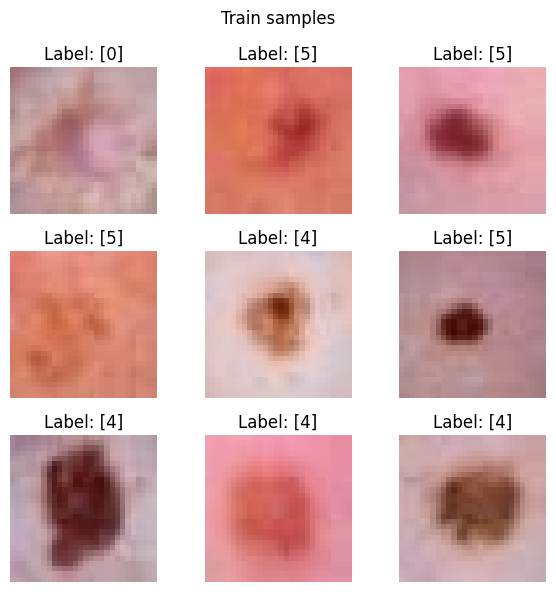

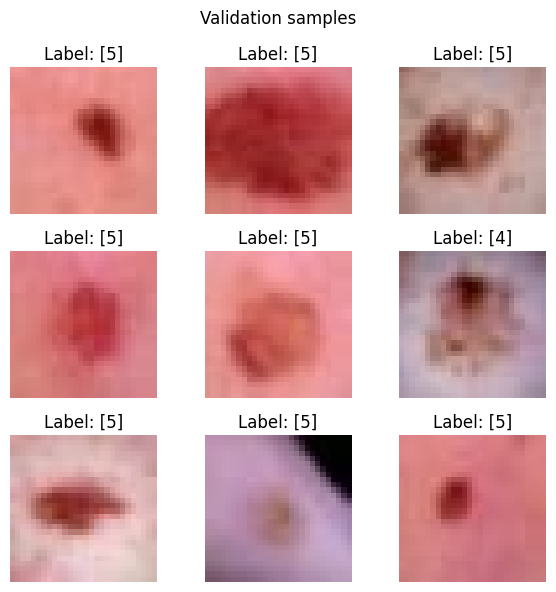

In [64]:

def show_dta(images, labels, title, num=9):
    plt.figure(figsize=(6,6))
    for i in range(num):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_dta(x_train, y_train, title="Train samples")
show_dta(x_val,   y_val,   title="Validation samples")

In [65]:

def data_distribution(labels, name="dataset"):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"data distribution for {name}:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples")

data_distribution(y_train, "Training set")
data_distribution(y_val,   "Validation set")

data distribution for Training set:
  Class 0: 616 samples
  Class 1: 670 samples
  Class 2: 845 samples
  Class 3: 520 samples
  Class 4: 884 samples
  Class 5: 2973 samples
  Class 6: 499 samples
data distribution for Validation set:
  Class 0: 33 samples
  Class 1: 52 samples
  Class 2: 110 samples
  Class 3: 12 samples
  Class 4: 111 samples
  Class 5: 671 samples
  Class 6: 14 samples


In [66]:
def preprocess_images(x):
    x = x.astype("float32") / 255.0
    if x.ndim == 4 and x.shape[-1] == 3:
        x = np.transpose(x, (0, 3, 1, 2))
    elif x.ndim == 3:
        x = np.expand_dims(x, axis=1)
    return x

x_train_proc = preprocess_images(x_train)
x_val_proc   = preprocess_images(x_val)

print("Processed x_train shape:", x_train_proc.shape)
print("Processed x_val shape:", x_val_proc.shape)

Processed x_train shape: (7007, 3, 28, 28)
Processed x_val shape: (1003, 3, 28, 28)


In [67]:
from torch.utils.data import Dataset, DataLoader

class MyDermDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        if labels.ndim == 2 and labels.shape[1] == 1:
            labels = labels[:, 0]
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx])
        img_tensor = torch.from_numpy(img)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return img_tensor, label_tensor

train_dataset = MyDermDataset(x_train_proc, y_train)
val_dataset   = MyDermDataset(x_val_proc,   y_val)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))

Number of training batches: 110
Number of validation batches: 16


In [68]:
class DermatologyCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(DermatologyCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model1 = DermatologyCNN(num_classes=7).to(device)
model2 = DermatologyCNN(num_classes=7).to(device)
print(model1)
print(model2)

DermatologyCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=128, out_features=7, bias=True)
  )
)
DermatologyCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kern

In [69]:
#criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion = nn.CrossEntropyLoss(reduction='none')
val_criterion   = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer1 = optim.AdamW(model1.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer2 = optim.AdamW(model2.parameters(), lr=1e-3, weight_decay=1e-4)
def forget_rate(epoch, max_epoch, max_forget=0.5):
    return min(max_forget, max_forget * epoch / max_epoch)

In [70]:
def train_one_epoch_coteaching(
    model1, model2,
    optimizer1, optimizer2,
    loader, criterion,
    epoch, num_epochs, device
):
    model1.train()
    model2.train()

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out1 = model1(imgs)
        out2 = model2(imgs)

        loss1 = criterion(out1, labels)
        loss2 = criterion(out2, labels)

        remember_rate = 1 - forget_rate(epoch, num_epochs)
        num_remember = int(remember_rate * len(loss1))
        num_remember = max(num_remember, 1)

        _, idx1 = torch.topk(-loss1, num_remember)
        _, idx2 = torch.topk(-loss2, num_remember)

        optimizer1.zero_grad()
        loss_1_update = loss1[idx2].mean()
        loss_1_update.backward()
        optimizer1.step()

        optimizer2.zero_grad()
        loss_2_update = loss2[idx1].mean()
        loss_2_update.backward()
        optimizer2.step()



def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [71]:
num_epochs = 40
best_val_acc = 0.0
val_accs_m1 = []
val_accs_m2 = []
val_losses_m1 = []
val_losses_m2 = []
forget_rates = []

best_model_path = "best_model.pth"

for epoch in range(1, num_epochs + 1):
    fr = forget_rate(epoch, num_epochs)
    forget_rates.append(fr)
    train_one_epoch_coteaching(
        model1, model2,
        optimizer1, optimizer2,
        train_loader, criterion,
        epoch, num_epochs, device
    )

    val_loss1, val_acc1 = validate(model1, val_loader, val_criterion, device)
    val_loss2, val_acc2 = validate(model2, val_loader, val_criterion, device)

    val_losses_m1.append(val_loss1)
    val_losses_m2.append(val_loss2)
    val_accs_m1.append(val_acc1)
    val_accs_m2.append(val_acc2)

    print(f"Epoch {epoch:02d} | Val acc M1: {val_acc1:.4f}, M2: {val_acc2:.4f}")

    if max(val_acc1, val_acc2) > best_val_acc:
        best_val_acc = max(val_acc1, val_acc2)
        best_model = model1 if val_acc1 >= val_acc2 else model2
        torch.save(best_model.state_dict(), best_model_path)

Epoch 01 | Val acc M1: 0.6720, M2: 0.6670
Epoch 02 | Val acc M1: 0.6869, M2: 0.6889
Epoch 03 | Val acc M1: 0.6889, M2: 0.6929
Epoch 04 | Val acc M1: 0.7208, M2: 0.6859
Epoch 05 | Val acc M1: 0.6989, M2: 0.6939
Epoch 06 | Val acc M1: 0.6760, M2: 0.6800
Epoch 07 | Val acc M1: 0.6760, M2: 0.6959
Epoch 08 | Val acc M1: 0.6939, M2: 0.5952
Epoch 09 | Val acc M1: 0.6969, M2: 0.6919
Epoch 10 | Val acc M1: 0.6989, M2: 0.7009
Epoch 11 | Val acc M1: 0.7089, M2: 0.6800
Epoch 12 | Val acc M1: 0.7188, M2: 0.7258
Epoch 13 | Val acc M1: 0.5494, M2: 0.5165
Epoch 14 | Val acc M1: 0.6750, M2: 0.6899
Epoch 15 | Val acc M1: 0.7119, M2: 0.7149
Epoch 16 | Val acc M1: 0.6919, M2: 0.7089
Epoch 17 | Val acc M1: 0.5125, M2: 0.6720
Epoch 18 | Val acc M1: 0.7198, M2: 0.7198
Epoch 19 | Val acc M1: 0.7049, M2: 0.7129
Epoch 20 | Val acc M1: 0.7198, M2: 0.6800
Epoch 21 | Val acc M1: 0.6491, M2: 0.7198
Epoch 22 | Val acc M1: 0.6909, M2: 0.6879
Epoch 23 | Val acc M1: 0.6899, M2: 0.7208
Epoch 24 | Val acc M1: 0.6959, M2:

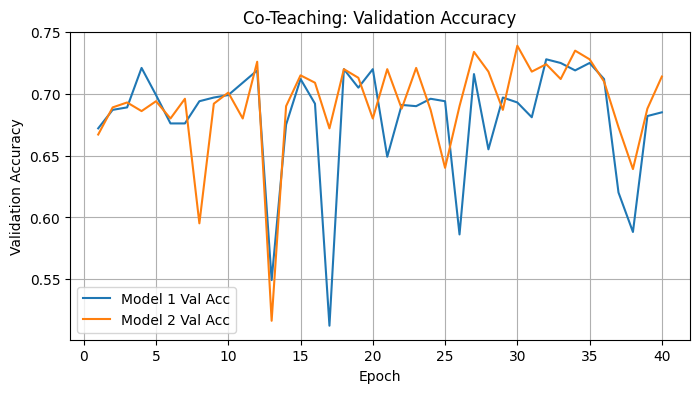

Best validation accuracy: 0.7387836490528414


In [72]:


epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8,4))
plt.plot(epochs, val_accs_m1, label='Model 1 Val Acc')
plt.plot(epochs, val_accs_m2, label='Model 2 Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Co-Teaching: Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


print("Best validation accuracy:", best_val_acc)

In [73]:
best_model = DermatologyCNN(num_classes=7).to(device)
best_model.load_state_dict(torch.load("best_model.pth", map_location=device))

val_loss_final, val_acc_final = validate(best_model, val_loader, val_criterion, device)
print(f"Final validation loss: {val_loss_final:.4f}, Final validation accuracy: {val_acc_final:.4f}")

Final validation loss: 1.2832, Final validation accuracy: 0.7388


In [39]:
def preprocess_images_for_inference(x):
    x = x.astype("float32") / 255.0
    if x.ndim == 4 and x.shape[-1] == 3:
        x = np.transpose(x, (0, 3, 1, 2))
    return x

def evaluate_on_new_dataset(test_images, test_labels, weights_path="best_model.pth", batch_size=128):
    x = test_images
    x = preprocess_images_for_inference(x)

    if test_labels.ndim == 2 and test_labels.shape[1] == 1:
        y = test_labels[:, 0].astype("int64")
    else:
        y = test_labels.astype("int64")

    test_dataset = MyDermDataset(x, y)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = DermatologyCNN(num_classes=7).to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return acc

In [60]:
test_data = np.load("candidate_dataset.npz")
x_test = test_data["x_val"]
y_test = test_data["y_val"]

test_acc = evaluate_on_new_dataset(x_test, y_test, weights_path="best_model.pth")
print("Hidden test accuracy:", test_acc)

Hidden test accuracy: 0.7507477567298105


In [45]:
stage1_model = DermatologyCNN(num_classes=7).to(device)
stage1_model.load_state_dict(torch.load("best_model.pth", map_location=device))
stage1_model.eval()
full_train_dataset = MyDermDataset(x_train_proc, y_train)
full_train_loader = DataLoader(full_train_dataset, batch_size=128, shuffle=False)

all_probs = []
all_preds = []

with torch.no_grad():
    for imgs, labels in full_train_loader:
        imgs = imgs.to(device)
        outputs = stage1_model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)  # (N_train, 7)
all_preds = np.concatenate(all_preds, axis=0)  # (N_train,)
print("all_probs shape:", all_probs.shape)
print("all_preds shape:", all_preds.shape)

all_probs shape: (7007, 7)
all_preds shape: (7007,)


In [47]:
if y_train.ndim == 2 and y_train.shape[1] == 1:
    y_train_flat = y_train[:, 0]
else:
    y_train_flat = y_train

predicted_class = all_preds

indices = np.arange(len(y_train_flat))
prob_of_noisy_label = all_probs[indices, y_train_flat]

print("Example probs for first 10 samples:", prob_of_noisy_label[:10])

confidence_threshold = 0.01

is_clean = (predicted_class == y_train_flat) & (prob_of_noisy_label >= confidence_threshold)

num_clean = is_clean.sum()
num_total = len(is_clean)
print(f"Estimated clean samples: {num_clean}/{num_total} ({num_clean/num_total:.2%})")

Example probs for first 10 samples: [3.4108245e-01 9.9827147e-01 9.9924964e-01 7.6062441e-01 1.0835392e-02
 6.2109739e-01 5.7463175e-01 4.6996982e-05 2.6405078e-01 3.3380898e-10]
Estimated clean samples: 3262/7007 (46.55%)


In [55]:
agree_mask = (predicted_class == y_train_flat)
num_agree = agree_mask.sum()
print(f"Model agrees with noisy label on {num_agree}/{num_total} samples ({num_agree/num_total:.2%})")

high_conf_mask = (prob_of_noisy_label >= 0.5)
num_high_conf = high_conf_mask.sum()
print(f"Samples where model gives >=0.5 prob to noisy label: {num_high_conf}/{num_total} ({num_high_conf/num_total:.2%})")

confidence_threshold = 0.5
is_clean = agree_mask & (prob_of_noisy_label >= confidence_threshold)
num_clean = is_clean.sum()
print(f"Clean samples with threshold {confidence_threshold}: {num_clean}/{num_total} ({num_clean/num_total:.2%})")

Model agrees with noisy label on 3262/7007 samples (46.55%)
Samples where model gives >=0.5 prob to noisy label: 3017/7007 (43.06%)
Clean samples with threshold 0.5: 3017/7007 (43.06%)


In [56]:
x_train_clean = x_train_proc[is_clean]
y_train_clean = y_train_flat[is_clean]

print("Filtered x_train_clean shape:", x_train_clean.shape)
print("Filtered y_train_clean shape:", y_train_clean.shape)

Filtered x_train_clean shape: (3017, 3, 28, 28)
Filtered y_train_clean shape: (3017,)


In [57]:
clean_train_dataset = MyDermDataset(x_train_clean, y_train_clean)
clean_train_loader = DataLoader(clean_train_dataset, batch_size=64, shuffle=True)

print("Number of batches in clean_train_loader:", len(clean_train_loader))

Number of batches in clean_train_loader: 48


In [58]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [61]:
stage2_model = DermatologyCNN(num_classes=7).to(device)
criterion_cl = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_cl = optim.AdamW(stage2_model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs_cl = 50
best_val_acc_cl = 0.0
best_model_path_cl = "best_model_confident_learning.pth"

train_losses_cl = []
val_losses_cl = []
train_accuracies_cl = []
val_accuracies_cl = []

for epoch in range(1, num_epochs_cl+1):
    train_loss, train_acc = train_one_epoch(stage2_model, clean_train_loader, criterion_cl, optimizer_cl, device)
    val_loss, val_acc = validate(stage2_model, val_loader, criterion_cl, device)

    train_losses_cl.append(train_loss)
    val_losses_cl.append(val_loss)
    train_accuracies_cl.append(train_acc)
    val_accuracies_cl.append(val_acc)

    print(f"[CL] Epoch {epoch:02d}/{num_epochs_cl} "
          f"- Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} "
          f"- Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")

    if val_acc > best_val_acc_cl:
        best_val_acc_cl = val_acc
        torch.save(stage2_model.state_dict(), best_model_path_cl)
        print(f"  --> [CL] New best CL model saved with val_acc = {best_val_acc_cl:.4f}")

[CL] Epoch 01/50 - Train loss: 0.9889, Train acc: 0.8124 - Val loss: 1.2671, Val acc: 0.6830
  --> [CL] New best CL model saved with val_acc = 0.6830
[CL] Epoch 02/50 - Train loss: 0.6393, Train acc: 0.9181 - Val loss: 1.4126, Val acc: 0.6790
[CL] Epoch 03/50 - Train loss: 0.6116, Train acc: 0.9321 - Val loss: 1.4146, Val acc: 0.6770
[CL] Epoch 04/50 - Train loss: 0.6074, Train acc: 0.9297 - Val loss: 1.3572, Val acc: 0.6142
[CL] Epoch 05/50 - Train loss: 0.5980, Train acc: 0.9443 - Val loss: 1.3720, Val acc: 0.6899
  --> [CL] New best CL model saved with val_acc = 0.6899
[CL] Epoch 06/50 - Train loss: 0.5905, Train acc: 0.9383 - Val loss: 1.1701, Val acc: 0.6949
  --> [CL] New best CL model saved with val_acc = 0.6949
[CL] Epoch 07/50 - Train loss: 0.5798, Train acc: 0.9450 - Val loss: 1.1835, Val acc: 0.7079
  --> [CL] New best CL model saved with val_acc = 0.7079
[CL] Epoch 08/50 - Train loss: 0.5789, Train acc: 0.9420 - Val loss: 1.2252, Val acc: 0.7029
[CL] Epoch 09/50 - Train los